<h1>ISW DATA PREPROCESSION</h1>

<h2>Checking data</h2>

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
df = pd.read_csv("isw_data_raw.csv")

In [110]:
df.head(5)

,url,date,title,text
0,https://understandingwar.org/research/russia-u...,"March 16, 2026","Russian Offensive Campaign Assessment, March 1...",Toplines Continued Ukrainian advances in Dnipr...
1,https://understandingwar.org/research/russia-u...,"March 15, 2026","Russian Offensive Campaign Assessment, March 1...",Toplines France will reportedly send Ukraine t...
2,https://understandingwar.org/research/russia-u...,"March 14, 2026","Russian Offensive Campaign Assessment, March 1...",Toplines Russian forces conducted a large-scal...
3,https://understandingwar.org/research/russia-u...,"March 13, 2026","Russian Offensive Campaign Assessment, March 1...",Toplines The United States lifted sanctions on...
4,https://understandingwar.org/research/russia-u...,"March 12, 2026","Russian Offensive Campaign Assessment, March 1...",Toplines A US delegation met with lead Russian...


In [111]:
df.shape

(1721, 4)

In [112]:
df.isna().sum()

url      0
date     0
title    0
text     1
dtype: int64

In [113]:
df[df["text"].isna()]

,url,date,title,text
198,https://understandingwar.org/research/russia-u...,"September 28, 2025","Russian Drone and Missile Strikes on Ukraine, ...",NaN


In [114]:
#after cheking the link, it was found out that this page contains only picture and no text. 
#Since we have another page on that day the best option is to delete this row.

df = df.dropna(subset=["text"])

print(df.isna().sum())
print(f"\nShape --> {df.shape}")

url      0
date     0
title    0
text     0
dtype: int64

Shape --> (1720, 4)


<h2>Changing date</h2>

In [115]:
df["date"] = pd.to_datetime(df["date"])#.dt.tz_localize("UTC")

print(df.dtypes)

df.head(5)

url              object
date     datetime64[ns]
title            object
text             object
dtype: object


,url,date,title,text
0,https://understandingwar.org/research/russia-u...,2026-03-16,"Russian Offensive Campaign Assessment, March 1...",Toplines Continued Ukrainian advances in Dnipr...
1,https://understandingwar.org/research/russia-u...,2026-03-15,"Russian Offensive Campaign Assessment, March 1...",Toplines France will reportedly send Ukraine t...
2,https://understandingwar.org/research/russia-u...,2026-03-14,"Russian Offensive Campaign Assessment, March 1...",Toplines Russian forces conducted a large-scal...
3,https://understandingwar.org/research/russia-u...,2026-03-13,"Russian Offensive Campaign Assessment, March 1...",Toplines The United States lifted sanctions on...
4,https://understandingwar.org/research/russia-u...,2026-03-12,"Russian Offensive Campaign Assessment, March 1...",Toplines A US delegation met with lead Russian...


<h2>Cleaning title</h2>

In [116]:
import re

def clean_title(title):
    return re.sub(r',\s+[A-Z][a-z]+\s+\d{1,2}(,\s+\d{4})?$', '', title).strip()

In [117]:
df["title_clean"] = df["title"].apply(clean_title)

df.head(5)

,url,date,title,text,title_clean
0,https://understandingwar.org/research/russia-u...,2026-03-16,"Russian Offensive Campaign Assessment, March 1...",Toplines Continued Ukrainian advances in Dnipr...,Russian Offensive Campaign Assessment
1,https://understandingwar.org/research/russia-u...,2026-03-15,"Russian Offensive Campaign Assessment, March 1...",Toplines France will reportedly send Ukraine t...,Russian Offensive Campaign Assessment
2,https://understandingwar.org/research/russia-u...,2026-03-14,"Russian Offensive Campaign Assessment, March 1...",Toplines Russian forces conducted a large-scal...,Russian Offensive Campaign Assessment
3,https://understandingwar.org/research/russia-u...,2026-03-13,"Russian Offensive Campaign Assessment, March 1...",Toplines The United States lifted sanctions on...,Russian Offensive Campaign Assessment
4,https://understandingwar.org/research/russia-u...,2026-03-12,"Russian Offensive Campaign Assessment, March 1...",Toplines A US delegation met with lead Russian...,Russian Offensive Campaign Assessment


In [118]:
df[["title", "title_clean"]]

,title,title_clean
0,"Russian Offensive Campaign Assessment, March 1...",Russian Offensive Campaign Assessment
1,"Russian Offensive Campaign Assessment, March 1...",Russian Offensive Campaign Assessment
2,"Russian Offensive Campaign Assessment, March 1...",Russian Offensive Campaign Assessment
3,"Russian Offensive Campaign Assessment, March 1...",Russian Offensive Campaign Assessment
4,"Russian Offensive Campaign Assessment, March 1...",Russian Offensive Campaign Assessment
...,...,...
1716,Ukraine Conflict Update 8,Ukraine Conflict Update 8
1717,Russia-Ukraine Warning Update: Russian Offensi...,Russia-Ukraine Warning Update: Russian Offensi...
1718,Ukraine Conflict Update 7,Ukraine Conflict Update 7
1719,Russia-Ukraine Warning Update: Initial Russian...,Russia-Ukraine Warning Update: Initial Russian...


<h2>Working on text</h2>

In [119]:
import re
import nltk
from nltk.corpus import stopwords

In [120]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Taisios\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<h3>Cleaning text</h3>

In [121]:
# #After several launches of the, it was decided that these words are unsuitable and create noise
custom_stopwords = {
    "russian", "ukrainian", "force", "forces",
    "near", "advance",

    "report", "reported", "reportedly",
    "claim", "claimed",

    "say", "said", "likely",
    "appear", "appears",

    "conduct", "conducted",
    "continue", "continued",

    "area", "region", "direction",
    "activity", "situation",

    "night", "day", "hour", "hours",

    "toplines", "published", "assessment",

    "general", "element", "source", "main",
    "west", "operate", "eastern", "western", "northern", "southern",
    "north", "south", "east", 
    "milblogger", "southwest", "objective", "northeast", "recently",
    "main",
    "effort",
    "russian military", "air", "mod", "staff", "group", "milbloggers", 
    "northwest", "caa", "southeast", "toward", "footage", "authority", "kreminna"
}

bad_phrases = {
    "claim russian",
    "force continue",
    "ukrainian force",
    "main effort",
    "russian milblogger",
    "milblogger claim",
    "oblast russian",
    "general staff",
    "russian objective"
}

def remove_custom_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in custom_stopwords and word not in bad_phrases]
    return " ".join(words)

In [122]:
def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

#---------------cuting off everything after references-------------------------
    if "references" in text:
        text = text.split("references")[0]

#--------------removing something like "[1]https.."---------------------------
    
    tail_pattern = r'(\[\d+\]\s*(https?://|www\.|[\w-]+\s+dot\s+).*)$'
    text = re.sub(tail_pattern, ' ', text, flags=re.IGNORECASE | re.DOTALL)

#---------------removing "click here"-------------------------
    text = re.sub(r'click here[^.]*\.', ' ', text)

#---------------removing url ----------------------------
    text = re.sub(r'http\S+|www\S+', ' ', text)

#---------------removing "[1]"-------------------------
    text = re.sub(r'\[\d+\]', ' ', text)

#---------------removing some unneeded phrases-------------------------
    text = re.sub(r'toplines', ' ', text)
    text = re.sub(r'institute for the study of war', ' ', text)
    text = re.sub(r'russia team', ' ', text)
    text = re.sub(r'isw published[^.]*', ' ', text)
    text = re.sub(r'isw report[^.]*', ' ', text)
    text = re.sub(r'\bisw\b', ' ', text)
    text = re.sub(r'\bdot\b', ' ', text)
    text = re.sub(r'\b(http|https|www|html|htm)\b', ' ', text)

#---------------removing time-------------------------
    text = re.sub(r'\b\d{1,2}:\d{2}\s*(am|pm)\s*(est|et)?\b', ' ', text)
    text = re.sub(r'\b\d{1,2}\s*(am|pm)\s*(est|et)?\b', ' ', text)

#---------------leaving only letters and spaces----------------
    text = re.sub(r'[^a-z\s]', ' ', text)

#---------------removing unneeded spaces-------------------------
    text = re.sub(r'\s+', ' ', text).strip()

#---------------removing months-----------------------------------    
    months = r'\b(january|february|march|april|may|june|july|august|september|october|november|december)\b'
    text = re.sub(months, ' ', text)

#---------------removing stopwords--------------------------------
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]

    return " ".join(words)

In [123]:
df["text_clean"] = df["text"].apply(preprocess_text)
df[["text", "text_clean"]]

,text,text_clean
0,Toplines Continued Ukrainian advances in Dnipr...,continued ukrainian advances dnipropetrovsk ob...
1,Toplines France will reportedly send Ukraine t...,france reportedly send ukraine newest version ...
2,Toplines Russian forces conducted a large-scal...,russian forces conducted large scale series dr...
3,Toplines The United States lifted sanctions on...,united states lifted sanctions russian oil alr...
4,Toplines A US delegation met with lead Russian...,delegation met lead russian negotiator russian...
...,...,...
1716,"Institute for the Study of War, Russia Team IS...",daily synthetic product covers key events rela...
1717,"Mason Clark, George Barros, and Kateryna Stepa...",mason clark george barros kateryna stepanenko ...
1718,Russia Team February 24 ISW published its most...,daily synthetic product covers key events rela...
1719,"February 24, 3:00 pm EST Russian President Vla...",russian president vladimir putin began large s...


<h4>Cheking if cleaning worked like needed</h4>

In [124]:
print(df["text_clean"][0])

continued ukrainian advances dnipropetrovsk oblast likely constraining russian offensive operations oleksandrivka direction soon threaten russian offensive operations hulyaipole direction ukrainian forces reportedly liberated square kilometers oleksandrivka hulyaipole directions late two separate drives ukrainian military observer kostyantyn mashovets reported ukrainian forces made additional tactical penetrations within past week since including entering sichneve east oleksandrivka reaching eastern outskirts voskresenska east sichneve advancing toward novoivanivka southeast oleksandrivka entering advancing southeastern novomykolaivka north novoivanivka seizing rybne southwest novomykolaivka mashovets statements indicate ukrainian forces likely also liberated sichneve vorone southwest sichneve mashovets assessed elements russian motorized rifle brigade army corps eastern military district emd operating east vovcha river likely withdraw voskresenka maliivka line northeast oleksandrivka 

In [125]:
print(df["text_clean"][1700])

critical threats project aei daily synthetic product covers key events related renewed russian aggression ukraine key takeaways russian forces advanced rapidly eastern outskirts kyiv likely sumy axis attempt encircle attack capital east bank dnipro coming hours russian troops press ground offensive kharkiv last hours instead diverted forces west southeast likely supporting efforts kyiv around donbas respectively russian troops surrounded mariupol attacking brutally destroy compel capitulation russian forces renewed ground advance mykolayiv secured kherson city likely set conditions attack toward odesa russian naval infantry likely poised conduct amphibious landings near odesa russian forces secured close securing reliable ground route crimea odesa kremlin dramatically limited russia already isolated domestic information environment criminalized unfavorable coverage war ukraine setting conditions improve domestic efficacy information operations ukraine attempting increase flow informati

<h2>Lemmatization</h2>

In [126]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

In [127]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Taisios\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Taisios\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Taisios\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [128]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [129]:
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    if not isinstance(text, str):
        return ""

    words = text.split()
    pos_tags = pos_tag(words)

    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    ]

    return " ".join(lemmatized)

df["lemm_text_clean"] = df["text_clean"].apply(lemmatize_text)

In [130]:
df["lemm_text_clean"] = df["lemm_text_clean"].apply(remove_custom_stopwords)

In [131]:
df[["text_clean", "lemm_text_clean"]]

,text_clean,lemm_text_clean
0,continued ukrainian advances dnipropetrovsk ob...,dnipropetrovsk oblast constrain offensive oper...
1,france reportedly send ukraine newest version ...,france send ukraine new version samp anti airc...
2,russian forces conducted large scale series dr...,large scale series drone missile strike ukrain...
3,united states lifted sanctions russian oil alr...,united state lift sanction oil already tankers...
4,delegation met lead russian negotiator russian...,delegation meet lead negotiator direct investm...
...,...,...
1716,daily synthetic product covers key events rela...,daily synthetic product cover key event relate...
1717,mason clark george barros kateryna stepanenko ...,mason clark george barros kateryna stepanenko ...
1718,daily synthetic product covers key events rela...,daily synthetic product cover key event relate...
1719,russian president vladimir putin began large s...,president vladimir putin begin large scale inv...


<h4>Cheking if lemmatization worked like needed</h4>

In [132]:
print(df["lemm_text_clean"][0])

dnipropetrovsk oblast constrain offensive operation oleksandrivka soon threaten offensive operation hulyaipole liberate square kilometer oleksandrivka hulyaipole late two separate drive military observer kostyantyn mashovets make additional tactical penetration within past week since include enter sichneve oleksandrivka reach outskirt voskresenska sichneve novoivanivka oleksandrivka enter southeastern novomykolaivka novoivanivka seize rybne novomykolaivka mashovets statement indicate also liberate sichneve vorone sichneve mashovets assess motorize rifle brigade army corp military district emd vovcha river withdraw voskresenka maliivka line oleksandrivka defend counterattack mashovets note within two kilometer hulyaipole velyka novosilka road prevent use road logistics transport equipment even though yet across mashovets oleksandrivka switch active defense rather active offensive operation constrain aligns reduce tempo ground operation recent week mashovets still hold berezove krasnohir

In [133]:
print(df["lemm_text_clean"][1700])

critical threat project aei daily synthetic product cover key event relate renew aggression ukraine key takeaway rapidly outskirt kyiv sumy axis attempt encircle attack capital bank dnipro come troops press ground offensive kharkiv last instead divert support kyiv around donbas respectively troop surround mariupol attack brutally destroy compel capitulation renew ground mykolayiv secure kherson city set condition attack odesa naval infantry poise amphibious landing odesa secure close secure reliable ground route crimea odesa kremlin dramatically limit russia already isolate domestic information environment criminalize unfavorable coverage war ukraine setting condition improve domestic efficacy information operation ukraine attempt increase flow information russia invasion ukraine citizen increase domestic opposition war kremlin set condition justify potential conscription aggressive operation ukraine defense ministry foreign citizen fight ukraine consider legal combatant protect intern

<h3>Tf-Idf</h3>

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [135]:
df_grouped = df.groupby("date")["lemm_text_clean"].apply(lambda x: " ".join(x)).reset_index()

df_grouped

,date,lemm_text_clean
0,2022-02-24,president vladimir putin begin large scale inv...
1,2022-02-25,mason clark george barros kateryna stepanenko ...
2,2022-02-26,mason clark george barros katya stepanenko ax ...
3,2022-02-27,mason clark george barros kateryna stepanenko ...
4,2022-02-28,mason clark george barros kateryna stepanenko ...
...,...,...
1256,2026-03-12,delegation meet lead negotiator direct investm...
1257,2026-03-13,united state lift sanction oil already tankers...
1258,2026-03-14,large scale series drone missile strike ukrain...
1259,2026-03-15,france send ukraine new version samp anti airc...


In [136]:
vectorizer = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9
)


tfidf = vectorizer.fit_transform(df_grouped["lemm_text_clean"])
print(f"Shape --> {tfidf.shape}")

Shape --> (1261, 100)


<h4>Cheking tf-idf</h4>

In [137]:
import numpy as np

In [138]:
mean_tfidf = tfidf.mean(axis=0).A1
print(mean_tfidf)

[0.04350628 0.10565909 0.1492489  0.04322386 0.04146495 0.05379697
 0.08023561 0.05617564 0.0970994  0.0539647  0.03600589 0.05613684
 0.05599777 0.054926   0.05026696 0.03644791 0.0607679  0.05355242
 0.04904879 0.06035747 0.0726897  0.05802418 0.20130369 0.04982851
 0.03839507 0.06261971 0.03659531 0.04653793 0.05758834 0.04759011
 0.04579106 0.05220848 0.03723258 0.04434776 0.05013942 0.06549326
 0.06321055 0.04373905 0.08282182 0.05113519 0.04470187 0.04136107
 0.04229437 0.05683327 0.06249127 0.0585089  0.04803013 0.04176908
 0.09917218 0.07784636 0.10748595 0.10652877 0.05088578 0.0546307
 0.04893571 0.05406479 0.04383886 0.08525796 0.05095987 0.06765114
 0.05534134 0.05144593 0.06191733 0.11689577 0.04546336 0.06499483
 0.05343113 0.04353894 0.06768922 0.04664844 0.13407278 0.04470112
 0.03394755 0.0631221  0.10792845 0.04339207 0.0413359  0.03628611
 0.04837763 0.05467044 0.05395355 0.04664227 0.05173127 0.05737931
 0.03985615 0.05246647 0.04274985 0.05944221 0.04428647 0.06870

In [139]:
# features = vectorizer.get_feature_names_out()

# custom_stopwords = {
#     "russian", "ukrainian", "force", "forces",
#     "near", "advance",

#     "report", "reported", "reportedly",
#     "claim", "claimed",

#     "say", "said", "likely",
#     "appear", "appears",

#     "conduct", "conducted",
#     "continue", "continued",

#     "area", "region", "direction",
#     "activity", "situation",

#     "night", "day", "hour", "hours",

#     "toplines", "published", "assessment",

#     "general", "element", "source", "main",
#     "west", "operate", "eastern", "western", "northern", "southern",
#     "north", "south", "east", 
#     "milblogger", "southwest", "objective", "northeast", "recently",
#     "main",
#     "effort",
#     "russian military", "air", "mod", "staff", "group", "milbloggers", "northwest"
# }

# bad_phrases = {
#     "claim russian",
#     "force continue",
#     "ukrainian force",
#     "main effort",
#     "russian milblogger",
#     "milblogger claim",
#     "oblast russian",
#     "general staff",
#     "russian objective"
# }

# mask = [
#     (word not in custom_stopwords) and (word not in bad_phrases)
#     for word in features
# ]

# filtered_scores = mean_tfidf[mask]
# filtered_features = features[mask]

# top_n = 20
# top_indices = np.argsort(filtered_scores)[::-1][:top_n+1]

# top_df = pd.DataFrame({
#     "word": filtered_features[top_indices],
#     "score": filtered_scores[top_indices]
# })

# top_df

<h3>Graphics</h3>

<h5>1</h5>

In [140]:
features = vectorizer.get_feature_names_out()

top_n = 20
top_indices = np.argsort(mean_tfidf)[::-1][:top_n+1]

top_df = pd.DataFrame({
    "word": features[top_indices],
    "score": mean_tfidf[top_indices]
})

top_df

,word,score
0,drone,0.201304
1,bakhmut,0.149249
2,putin,0.134073
3,pokrovsk,0.116896
4,rifle,0.107928
5,motorize,0.107486
6,motorize rifle,0.106529
7,avdiivka,0.105659
8,missile,0.099172
9,brigade,0.097099


In [141]:
# words = filtered_features[top_indices]
# scores = filtered_scores[top_indices]

words = features[top_indices]
scores = mean_tfidf[top_indices]

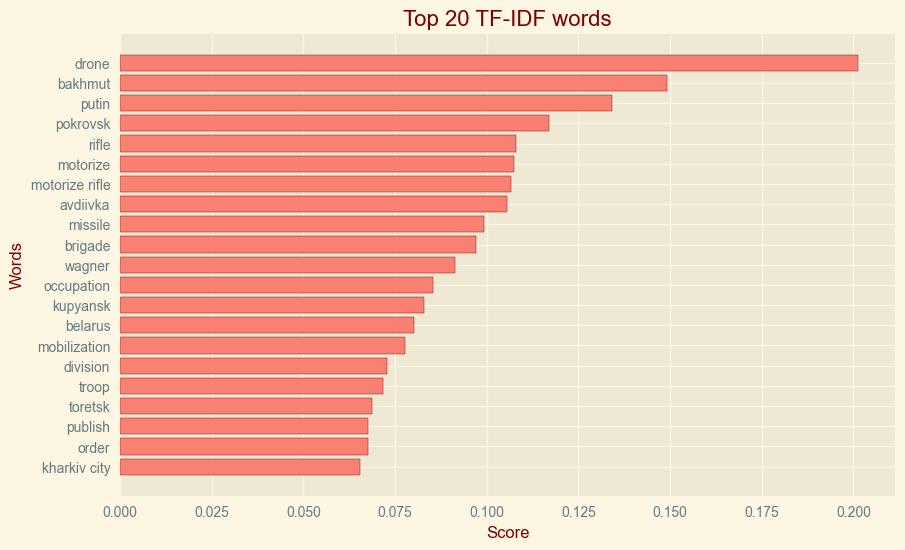

In [142]:
plt.style.use("Solarize_Light2")

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], scores[::-1], color="salmon", edgecolor="maroon")
plt.title("Top 20 TF-IDF words", color="maroon")
plt.xlabel("Score", color="maroon")
plt.ylabel("Words",  color="maroon")
plt.show()

<h5>2</h5>

In [143]:
df["word_count"] = df["lemm_text_clean"].apply(lambda x: len(x.split()))

print(f"Max words in one text --> {df["word_count"].max()}")
print(f"Min words in one text --> {df["word_count"].min()}")

Max words in one text --> 32436
Min words in one text --> 22


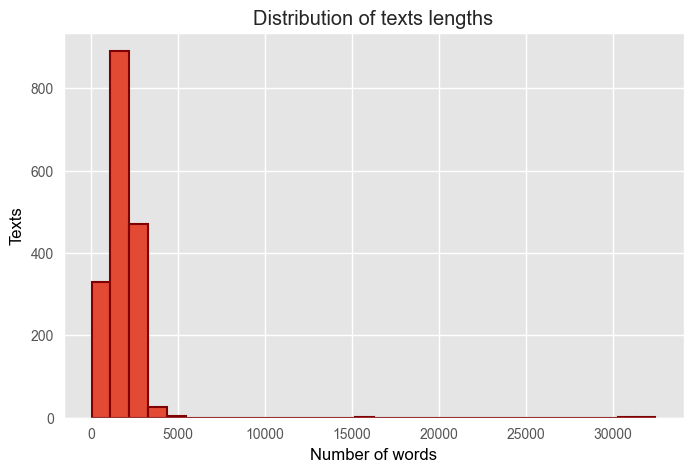

In [144]:
plt.style.use("ggplot")

plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=30, edgecolor="maroon", linewidth=1.5)

plt.title("Distribution of texts lengths")
plt.xlabel("Number of words", color="black")
plt.ylabel("Texts", color="black")
plt.show()

<h5>3</h5>

In [145]:
words_to_track = ["attack", "drone", "strike", "missile",]

In [146]:
data = {}

for word in words_to_track:
    df[word] = df["lemm_text_clean"].apply(lambda x: x.split().count(word))
    data[word] = df.groupby("date")[word].sum()

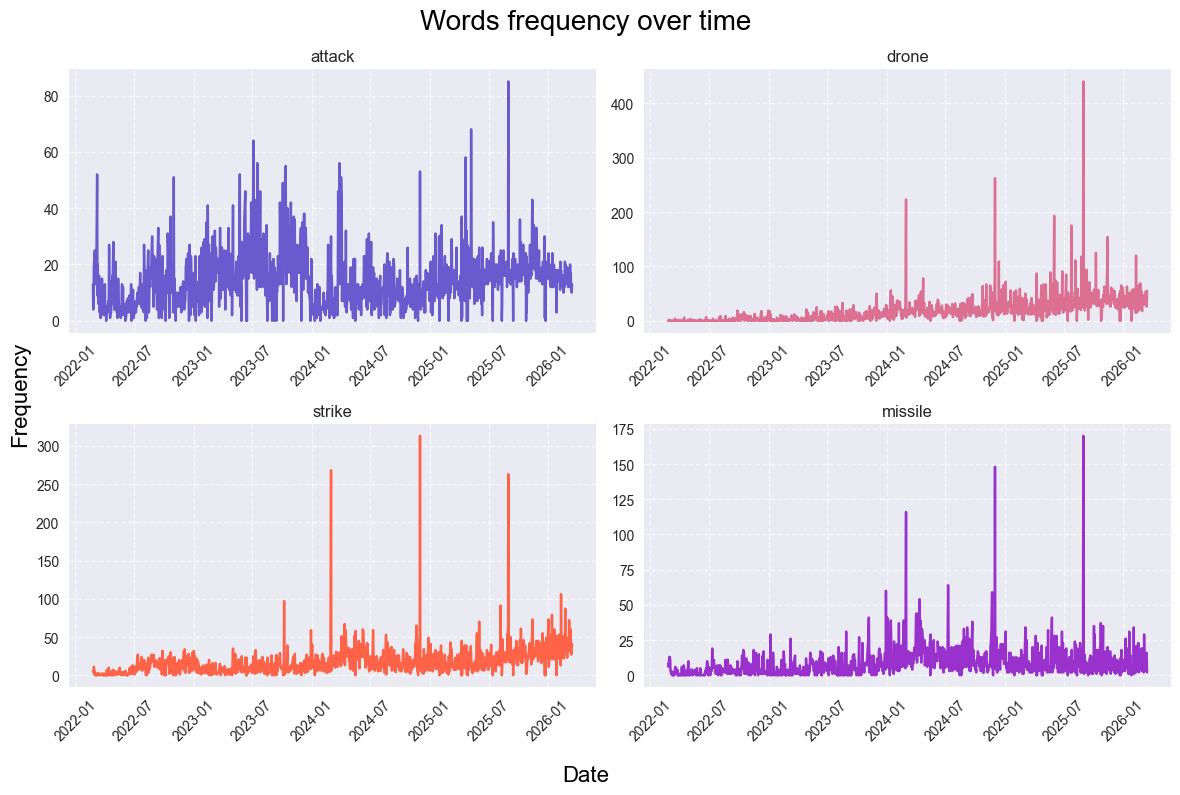

In [147]:
plt.style.use("seaborn-v0_8")

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 
axes = axes.flatten() 
colors = ["slateblue", "palevioletred", "tomato", "darkorchid"]

for i, word in enumerate(words_to_track[:4]):
    ax = axes[i]
    ax.plot(
        data[word].index,
        data[word].values,
        color=colors[i]
    )
    
    ax.set_title(word)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle="--", alpha=0.7)

fig.supxlabel("Date", size=16, color="black")
fig.supylabel("Frequency",size=16, color="black")
fig.suptitle("Words frequency over time", fontsize=20, color="black")

plt.tight_layout()
plt.show()

<h2>Preparings for merging</h2>

In [148]:
tfidf_df = pd.DataFrame(tfidf.toarray())


In [149]:
tfidf_df["date"] = df_grouped["date"].values

In [150]:
tfidf_df

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,date
0,0.366955,0.0,0.00000,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.020152,0.117193,0.069608,0.022746,0.205440,0.0,0.166083,0.000000,0.000000,2022-02-24
1,0.191202,0.0,0.00000,0.018067,0.017964,0.021772,0.306063,0.248766,0.050400,0.016219,...,0.084000,0.065134,0.096718,0.000000,0.102762,0.0,0.051922,0.000000,0.000000,2022-02-25
2,0.161206,0.0,0.00000,0.108806,0.043275,0.000000,0.163841,0.054478,0.080939,0.000000,...,0.060704,0.058839,0.046597,0.022840,0.082516,0.0,0.104231,0.026595,0.000000,2022-02-26
3,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.172444,0.114677,0.127784,0.000000,...,0.063892,0.000000,0.098088,0.048078,0.000000,0.0,0.131645,0.000000,0.000000,2022-02-27
4,0.410602,0.0,0.00000,0.046559,0.000000,0.000000,0.394359,0.505082,0.028862,0.013932,...,0.014431,0.055950,0.000000,0.032578,0.088272,0.0,0.193271,0.000000,0.000000,2022-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1256,0.028042,0.0,0.00000,0.026497,0.017565,0.159659,0.024938,0.000000,0.139621,0.063431,...,0.024639,0.031842,0.047282,0.037081,0.066983,0.0,0.033844,0.043178,0.039644,2026-03-12
1257,0.000000,0.0,0.01627,0.024122,0.071954,0.159879,0.034053,0.000000,0.123364,0.010827,...,0.044860,0.021741,0.038739,0.000000,0.034300,0.0,0.080876,0.029480,0.043308,2026-03-13
1258,0.000000,0.0,0.00000,0.000000,0.045520,0.183898,0.043085,0.000000,0.170278,0.041097,...,0.028380,0.013754,0.114368,0.096099,0.000000,0.0,0.000000,0.037300,0.041097,2026-03-14
1259,0.000000,0.0,0.00000,0.045633,0.015124,0.183305,0.042946,0.000000,0.099008,0.068274,...,0.141440,0.054837,0.048857,0.000000,0.000000,0.0,0.029143,0.018590,0.054619,2026-03-15


In [151]:
tfidf_df.isna().sum().sum()


np.int64(0)

In [152]:
tfidf_df.shape

(1261, 101)

<h4>Shifting days</h4>

In [153]:
tfidf_df['date'] = pd.to_datetime(tfidf_df['date']) + pd.Timedelta(days=1)

<h4>Adding hours for better merge later</h4>

In [154]:
tfidf_df_hourly = tfidf_df.loc[tfidf_df.index.repeat(24)].copy()

tfidf_df_hourly['hour'] = tfidf_df_hourly.groupby(level=0).cumcount()

tfidf_df_hourly['datetime'] = tfidf_df_hourly['date'] + pd.to_timedelta(tfidf_df_hourly['hour'], unit='h')

tfidf_df_hourly.head(30)

,0,1,2,3,4,5,6,7,8,9,...,93,94,95,96,97,98,99,date,hour,datetime
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,0,2022-02-25 00:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,1,2022-02-25 01:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,2,2022-02-25 02:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,3,2022-02-25 03:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,4,2022-02-25 04:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,5,2022-02-25 05:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,6,2022-02-25 06:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,7,2022-02-25 07:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,8,2022-02-25 08:00:00
0,0.366955,0.0,0.0,0.000000,0.043097,0.000000,0.244749,0.135634,0.100758,0.038909,...,0.069608,0.022746,0.205440,0.0,0.166083,0.0,0.0,2022-02-25,9,2022-02-25 09:00:00


In [155]:
tfidf_df_hourly = tfidf_df_hourly.drop(columns=['date', 'hour'])

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,datetime
0,0.366955,0.0,0.0,0.0,0.043097,0.0,0.244749,0.135634,0.100758,0.038909,...,0.020152,0.117193,0.069608,0.022746,0.20544,0.0,0.166083,0.0,0.0,2022-02-25 00:00:00
0,0.366955,0.0,0.0,0.0,0.043097,0.0,0.244749,0.135634,0.100758,0.038909,...,0.020152,0.117193,0.069608,0.022746,0.20544,0.0,0.166083,0.0,0.0,2022-02-25 01:00:00


In [157]:
new_colums = []

counter = 1
for col in tfidf_df_hourly.columns:
    if col != 'datetime':
        new_colums.append(f'isw_tfidf_{counter}')
        counter += 1
    else:
        new_colums.append('datetime')

tfidf_df_hourly.columns = new_colums

In [158]:
tfidf_df_hourly.head(2)

,isw_tfidf_1,isw_tfidf_2,isw_tfidf_3,isw_tfidf_4,isw_tfidf_5,isw_tfidf_6,isw_tfidf_7,isw_tfidf_8,isw_tfidf_9,isw_tfidf_10,...,isw_tfidf_92,isw_tfidf_93,isw_tfidf_94,isw_tfidf_95,isw_tfidf_96,isw_tfidf_97,isw_tfidf_98,isw_tfidf_99,isw_tfidf_100,datetime
0,0.366955,0.0,0.0,0.0,0.043097,0.0,0.244749,0.135634,0.100758,0.038909,...,0.020152,0.117193,0.069608,0.022746,0.20544,0.0,0.166083,0.0,0.0,2022-02-25 00:00:00
0,0.366955,0.0,0.0,0.0,0.043097,0.0,0.244749,0.135634,0.100758,0.038909,...,0.020152,0.117193,0.069608,0.022746,0.20544,0.0,0.166083,0.0,0.0,2022-02-25 01:00:00


In [159]:
#df.to_csv("isw_data_preprocessed.csv", index=False)

tfidf_df_hourly.to_csv("isw_tfidf.csv", index=False)